In [11]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1


# Multishank sessions only
multishank_mouse_days = {
    21: [15,16,17,18,22],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41,42,43,44],
    25: [16,17,18,25,26],
    26: [13,15,16,19,20,21,22],
    27: [18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

multishank_mouse_days = {
    27: [23,24,26],
    25: [24, 25],
    26: [19],
    28: [23],    
}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np

def make_annotations(mouse, path=None):
    Mouse = f'M{mouse}'

    data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
    shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
    clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
    clusters_df = clusters_df[clusters_df['mouse'] == mouse]
    shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
    clusters_df = reconstruct_shank_id(clusters_df, mouse)
    probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
    adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)
    
    ymin = -300; ymax = 3000
    xmin = -200; xmax = 1000
    xs = np.arange(xmin, xmax, 1)
    ys = np.arange(ymin, ymax, 1)

    if os.path.exists(f"{path}/M{mouse}_annotations.npy"):
        # Load annotations and colors from disk
        annotations = np.load(f"{path}/M{mouse}_annotations.npy", allow_pickle=True)
        annotation_colors = np.load(f"{path}/M{mouse}_annotation_colors.npy", allow_pickle=True)
        return annotations, annotation_colors, xs, ys
    
    else:
        annotations = np.zeros((len(ys), len(xs)), dtype=object)
        for yi, y in enumerate(ys):
            for xi, x in enumerate(xs):
                coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
                z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
                annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
                if len(structure_set[structure_set['id'] == annotation_index]) ==1:
                    annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
                else:
                    annotation ='root' # out of brain
                annotations[yi,xi] = annotation

        annotation_colors = get_annotation_colors_2D(annotations)

        # Save
        np.save(f"{path}/M{mouse}_annotations.npy", annotations)
        np.save(f"{path}/M{mouse}_annotation_colors.npy", annotation_colors)

    return annotations, annotation_colors, xs, ys

In [13]:
def plot_cells_on_annotated_probe(mouse, day, gcs, ngs, all_cells, path='/Users/harryclark/Documents/spatial-manifolds/data'):
    """
    Plot GCS and NGS cells on the annotated probe map for a given mouse and day.
    GCS cells are shown in red, NGS cells in blue, all other cells in gray.
    """
    print(f'printing probe map for Mouse {mouse} Day {day} with {len(gcs)} GCS cells, {len(ngs)} NGS cells, and {len(all_cells)} total cells')
    # Load annotations and colors
    annotations, annotation_colors, xs, ys = make_annotations(mouse, path=path)
    unique_colors = np.unique(annotation_colors)
    
    fig, ax = plt.subplots(figsize=(6, 10))
    # Plot annotation background
    for color_ in unique_colors:
        border_points = extract_border(annotation_colors, color_, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax.scatter(x_points, y_points, color=color_, s=1, rasterized=True)
    plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa',
                   probe_alpha=0.5, contacts_alpha=0.5, probe_color='grey', probe_edgecolor='black')
    
    # Plot all cells in gray
    ax.scatter(all_cells.probe_x.values, all_cells.probe_y.values, marker='o', color="grey", alpha=0.3, s=10, label='All')
    if len(ngs) > 0:
        ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color='#3171ae', alpha=0.7, s=30, label='NGS')
    if len(gcs) > 0:
        ax.scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color='#c04744', alpha=0.7, s=30, label='GCS')
    
    ax.set_ylim([0, 3000])
    ax.set_xlim([-100, 900])
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M{mouse}D{day}_probe_map.pdf')
    plt.close()

for mouse, days in multishank_mouse_days.items():
    for day in days:
        gcs, ngs, all = classify_cells_both_sessions(mouse=mouse, day=day, percentile_threshold=95, verbose=False)
        plot_cells_on_annotated_probe(mouse, day, gcs, ngs, all)


printing probe map for Mouse 27 Day 23 with 14 GCS cells, 64 NGS cells, and 80 total cells
hi
printing probe map for Mouse 27 Day 24 with 5 GCS cells, 136 NGS cells, and 145 total cells
hi
printing probe map for Mouse 27 Day 26 with 8 GCS cells, 10 NGS cells, and 19 total cells
hi
printing probe map for Mouse 25 Day 24 with 26 GCS cells, 34 NGS cells, and 63 total cells
hi
printing probe map for Mouse 25 Day 25 with 44 GCS cells, 49 NGS cells, and 108 total cells
hi
printing probe map for Mouse 26 Day 19 with 47 GCS cells, 213 NGS cells, and 280 total cells
hi
printing probe map for Mouse 28 Day 23 with 13 GCS cells, 106 NGS cells, and 137 total cells
hi


In [14]:
import numpy as np

def make_hit_mask(beh, trial_types):
    """
    Build a boolean mask over trials marking hits for specific trial types.

    Parameters
    ----------
    beh : dict-like
        Behaviour output from compute_vr_tcs; expects beh['trials']
        with at least columns 'type' and 'hit'.
    trial_types : str, int, or list/tuple of these
        Trial type(s) to include (e.g. 'b', 'nb', or ['b', 'nb']).

    Returns
    -------
    mask : np.ndarray of bool, shape (n_trials,)
        True where trial is one of the requested types AND hit == 1,
        False otherwise.
    """
    trials = beh['trials']

    # Normalise trial_types to a list
    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]

    # Mask for requested types
    type_mask = trials['type'].isin(trial_types)

    # Mask for hits (assuming 1 = hit)
    hit_mask = trials['performance'] == 'hit'

    # Combined mask; length == number of rows in beh['trials']
    mask = (type_mask & hit_mask).to_numpy()

    return mask

def make_trialtype_mask(beh, trial_types):
    """
    Boolean mask over trials marking where the trial type is in trial_types,
    regardless of performance (hit/miss/etc.).
    """
    trials = beh['trials']

    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]

    type_mask = trials['type'].isin(trial_types)
    return type_mask.to_numpy()


Processing Mouse 27 Day 23...
14 GCS cells, 64 NGS cells, 80 total cells
Error processing cluster 318 on shank 2: all input arrays must have the same shape


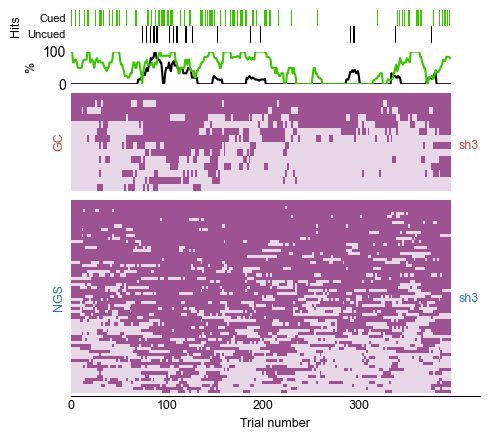

Processing Mouse 27 Day 26...
8 GCS cells, 10 NGS cells, 19 total cells


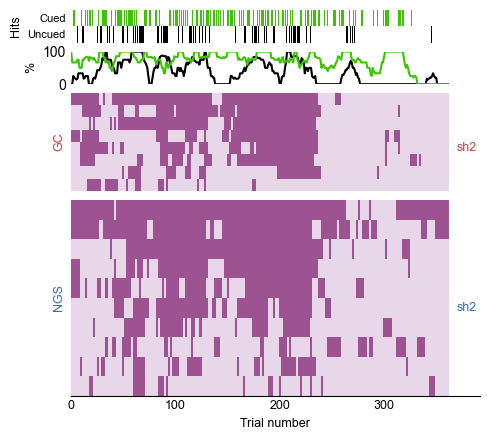

Processing Mouse 25 Day 24...
26 GCS cells, 34 NGS cells, 63 total cells
Error processing cluster 120 on shank 0: all input arrays must have the same shape


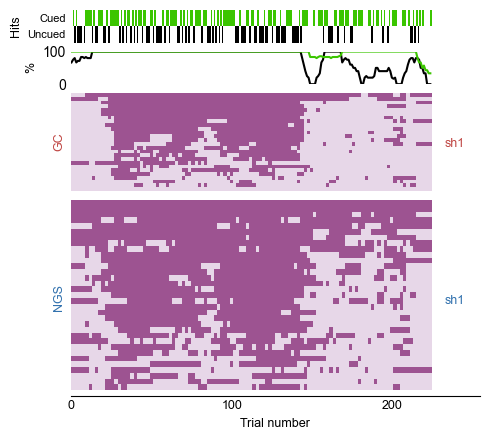

Processing Mouse 25 Day 25...
44 GCS cells, 49 NGS cells, 108 total cells


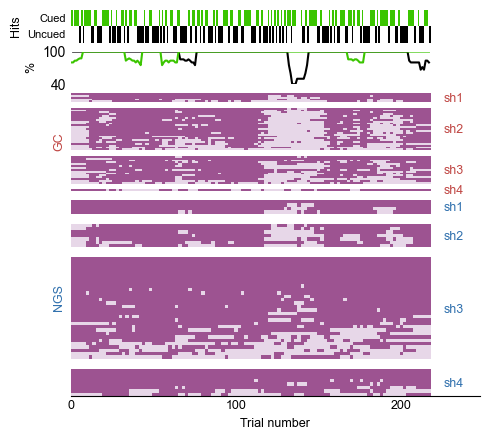

Processing Mouse 26 Day 19...
47 GCS cells, 213 NGS cells, 280 total cells


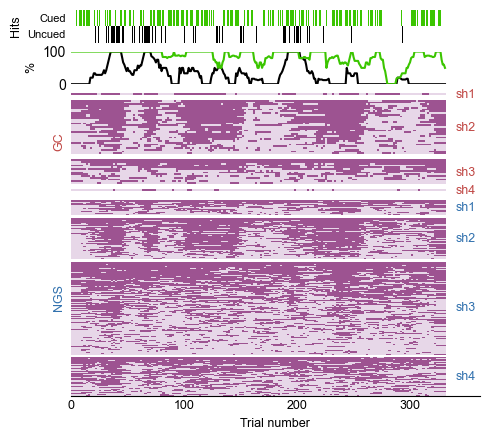

Processing Mouse 28 Day 23...
13 GCS cells, 106 NGS cells, 137 total cells
Error processing cluster 368 on shank 3: all input arrays must have the same shape


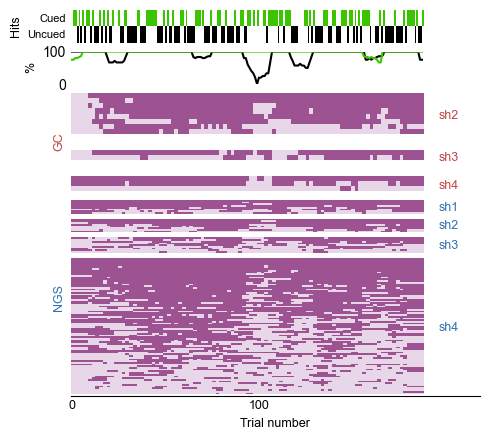

In [15]:
ngs_color = "#3171ae"  # NGS color for shank text
gc_color = "#c04744"   # GC color for shank text

multishank_mouse_days = {
    27: [23,26],
    25: [24,25],
    26: [19],
    28: [23],    
}
'''
multishank_mouse_days = {
    25: [25],
    26: [19], 
}'''

# --- Raster plot of task_anchored_labels for all cells, ordered by shank,
#     with rolling hit rate on top, HIT row below, then GCS and NGS rasters ---
for mouse, days in multishank_mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")
        
        gcs, ngs, all = classify_cells_both_sessions(
            mouse=mouse, day=day, percentile_threshold=95, verbose=False
        )
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False
        )
        last_ephys_time_bin = clusters[clusters.index[0]].count(
            bin_size=time_bs, time_units='ms'
        ).index[-1]
        print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all)} total cells')

        # Compute GCS task-anchored label rasters (ordered as in gcs DataFrame)
        gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
        gc_shank_ids = sorted(gcs['shank_id'].unique())
        gcs_cells_by_shank = {
            shank: gcs[gcs['shank_id'] == shank].cluster_id.values
            for shank in gc_shank_ids
        }
        gcs_labels = []
        gcs_rate_maps = []
        gcs_shank_order = []
        for shank in gc_shank_ids:
            for cluster_id in gcs_cells_by_shank[shank]:
                try:
                    tc = tcs[cluster_id] if cluster_id in tcs else None
                    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                    tc = tc[:last_ephys_bin]
                    tcs_to_use = {cluster_id: tc}
                    tcs_to_use[1000] = tc

                    results = spectral_analysis(tcs_to_use, tl, bs=bs)
                    spectrograms = results[3]
                    fvalid = results[5]
                    S = spectrograms.mean(0)
                    max_peaks = np.argmax(S, axis=0)
                    labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                    labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                    gcs_labels.append(labels)
                    gcs_rate_maps.append(tc)
                    gcs_shank_order.append(shank)
                except Exception as e:
                    print(f"Error processing GCS cluster {cluster_id}: {e}")

        # Sort GCS by shank, then by task-anchored sum descending within shank
        gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels])
        gcs_shank_arr = np.array(gcs_shank_order)
        gc_order = []
        for shank in gc_shank_ids:
            shank_indices = np.where(gcs_shank_arr == shank)[0]
            sorted_shank = shank_indices[np.argsort(-gcs_label_sums[shank_indices])]
            gc_order.extend(sorted_shank.tolist())
        gcs_labels = [gcs_labels[i] for i in gc_order]
        gcs_rate_maps = [gcs_rate_maps[i] for i in gc_order]
        gcs_shank_order = [gcs_shank_order[i] for i in gc_order]

        # Group NGS cells by shank
        ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
        shank_ids = sorted(ngs['shank_id'].unique())
        ngs_cells_by_shank = {
            shank: ngs[ngs['shank_id'] == shank].cluster_id.values
            for shank in shank_ids
        }

        # Flatten all cells, keeping shank info
        global_cell_list = []
        global_shank_list = []
        for shank in shank_ids:
            for cid in ngs_cells_by_shank[shank]:
                global_cell_list.append(cid)
                global_shank_list.append(shank)

        # Compute NGS task-anchored label rasters, ordered by shank
        avg_rate_maps = []
        all_labels = []
        cell_ids_ordered = []
        cell_shank_order = []

        for idx, (target_cluster_id, shank) in enumerate(
            zip(global_cell_list, global_shank_list)
        ):
            try:
                tcs_to_use = {
                    cluster_id: tcs[cluster_id]
                    for cluster_id in [target_cluster_id]
                    if cluster_id in tcs
                }
                tcs_to_use[1000] = tcs_to_use[target_cluster_id]

                tc = tcs[target_cluster_id]
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]

                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3]
                fvalid = results[5]
                S = spectrograms.mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
            
            except Exception as e:
                print(f"Error processing cluster {target_cluster_id} on shank {shank}: {e}")
                labels = np.full_like(labels, np.nan)

            avg_rate_maps.append(tc)
            cell_shank_order.append(shank)
            all_labels.append(labels)
            cell_ids_ordered.append(target_cluster_id)

        # Sort within each shank by task-anchored sum descending
        shank_arr = np.array(cell_shank_order)
        label_sums = np.array([np.nansum(lab == 1) for lab in all_labels])
        order = []
        for shank in shank_ids:
            shank_indices = np.where(shank_arr == shank)[0]
            sorted_shank = shank_indices[np.argsort(-label_sums[shank_indices])]
            order.extend(sorted_shank.tolist())
        order = np.array(order)

        # Pad both GCS and NGS label matrices to the same number of columns
        max_len = max(
            [len(lab) for lab in all_labels] + [len(lab) for lab in gcs_labels]
        )

        # --- Build GCS raster with 3 blank rows between shanks ---
        gc_blocks = []
        for shank in gc_shank_ids:
            block = [gcs_labels[i] for i in range(len(gcs_labels)) if gcs_shank_order[i] == shank]
            block_matrix = np.full((len(block), max_len), np.nan)
            for i, lab in enumerate(block):
                block_matrix[i, :len(lab)] = lab
            gc_blocks.append(block_matrix)
        labels_matrix_gcs = gc_blocks[0]
        for block in gc_blocks[1:]:
            blank = np.full((3, max_len), np.nan)
            labels_matrix_gcs = np.vstack([labels_matrix_gcs, blank, block])

        # --- Build NGS raster with 3 blank rows between shanks ---
        ngs_blocks = []
        for shank in shank_ids:
            block = [all_labels[idx] for idx in order if cell_shank_order[order[idx]] == shank]
            block_matrix = np.full((len(block), max_len), np.nan)
            for i, lab in enumerate(block):
                block_matrix[i, :len(lab)] = lab
            ngs_blocks.append(block_matrix)
        labels_matrix_ngs = ngs_blocks[0]
        for block in ngs_blocks[1:]:
            blank = np.full((3, max_len), np.nan)
            labels_matrix_ngs = np.vstack([labels_matrix_ngs, blank, block])

        # ------------------------------------------------------------------
        # Build a 2×max_len raster for HIT TRIALS using make_hit_mask:
        # Row 0: cued (B) hits, Row 1: uncued (NB) hits
        # ------------------------------------------------------------------
        nb_hit_mask = make_hit_mask(beh, 'nb')
        b_hit_mask  = make_hit_mask(beh, 'b')
        n_trials = len(nb_hit_mask)
        n_use = min(max_len, n_trials)
        hit_raster = np.full((2, max_len), np.nan)
        # Row 0: B hits (cued)
        hit_raster[0, :n_use][b_hit_mask[:n_use]] = 1
        # Row 1: NB hits (uncued)
        hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1

        # Custom colormap: 0=white, 1=green (cued), 2=black (uncued)
        from matplotlib.colors import ListedColormap, BoundaryNorm
        hit_cmap = ListedColormap(["white", "#3bc500", "black"])
        hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)

        # For imshow, set cued hits to 1, uncued hits to 2
        hit_raster_plot = np.zeros_like(hit_raster)
        hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
        hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

        # ------------------------------------------------------------------
        # Rolling average of hit rate for NB and B trials
        # ------------------------------------------------------------------
        window = 10
        kernel = np.ones(window) / window

        nb_type_mask = make_trialtype_mask(beh, 'nb')
        b_type_mask  = make_trialtype_mask(beh, 'b')
        nb_hits   = nb_hit_mask.astype(float)
        b_hits    = b_hit_mask.astype(float)
        nb_trials = nb_type_mask.astype(float)
        b_trials  = b_type_mask.astype(float)

        nb_num = np.convolve(nb_hits,   kernel, mode='same')
        nb_den = np.convolve(nb_trials, kernel, mode='same')
        b_num  = np.convolve(b_hits,    kernel, mode='same')
        b_den  = np.convolve(b_trials,  kernel, mode='same')

        nb_rolling = np.full_like(nb_num, np.nan, dtype=float)*100
        b_rolling  = np.full_like(b_num,  np.nan, dtype=float)*100
        nb_rolling[nb_den > 0] = nb_num[nb_den > 0] / nb_den[nb_den > 0] * 100
        b_rolling[b_den > 0]   = b_num[b_den > 0]   / b_den[b_den > 0] * 100

        nb_rolling_full = np.full(max_len, np.nan)
        b_rolling_full  = np.full(max_len, np.nan)
        nb_rolling_full[:n_use] = nb_rolling[:n_use]
        b_rolling_full[:n_use]  = b_rolling[:n_use]

        cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
        norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

        fig, axes = plt.subplots(
            4, 1, figsize=(5, 4.5), sharex=True,
            gridspec_kw={'height_ratios': [1, 1, 3, 6]}
        )

        axes[0].imshow(hit_raster_plot, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                       interpolation='nearest', rasterized=False)
        axes[0].set_yticks([0, 1])
        axes[0].set_yticklabels(['Cued', 'Uncued'], fontsize=8)
        axes[0].set_ylabel('Hits', fontsize=9)
        for spine in axes[0].spines.values(): spine.set_visible(False)
        axes[0].tick_params(left=False, bottom=False, labelleft=True, labelbottom=False, length=0)

        axes[1].plot(nb_rolling_full, color='black', label='NB hit rate')
        axes[1].plot(b_rolling_full,  color='#3bc500', label='B hit rate')
        axes[1].set_ylabel('%', fontsize=9)

        y_vals = np.concatenate([nb_rolling_full, b_rolling_full])
        finite = np.isfinite(y_vals)
        if finite.any():
            y_min, y_max = y_vals[finite].min(), y_vals[finite].max()
            if y_min == y_max:
                margin = 0.05 * (abs(y_min) if y_min != 0 else 1.0)
                y_min -= margin; y_max += margin
        else:
            y_min, y_max = 0.0, 100
        axes[1].set_ylim(y_min, y_max)
        axes[1].set_yticks(np.linspace(y_min, y_max, 2))
        for spine in axes[1].spines.values(): spine.set_visible(False)
        axes[1].tick_params(left=False, bottom=False, labelleft=True, labelbottom=False, length=0)

        axes[2].imshow(labels_matrix_gcs, aspect='auto', cmap=cmap, norm=norm,
                       interpolation='nearest', rasterized=False)
        axes[2].set_ylabel('GC', fontsize=9, color=gc_color)
        axes[2].set_yticks([])
        for spine in axes[2].spines.values(): spine.set_visible(False)
        axes[2].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False, length=0)

        # Add shank text ("sh1", "sh2", ...) at vertical midpoint of each GC shank block, in gc_color
        y_gc = 0
        for i, (block, shank) in enumerate(zip(gc_blocks, gc_shank_ids)):
            block_height = block.shape[0]
            y_mid = y_gc + block_height / 2
            axes[2].text(
                labels_matrix_gcs.shape[1] + 8, y_mid, f"sh{shank + 1}",
                fontsize=9, va='center', ha='left', color=gc_color, clip_on=False
            )
            y_gc += block_height + 3  # move past block and blank

        axes[3].imshow(labels_matrix_ngs, aspect='auto', cmap=cmap, norm=norm,
                       interpolation='nearest', rasterized=False)
        axes[3].set_xlabel('Trial number', fontsize=9)
        axes[3].set_ylabel('NGS', fontsize=9, color=ngs_color)
        axes[3].set_yticks([])
        for spine in axes[3].spines.values(): spine.set_visible(False)
        axes[3].tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

        # Add shank text ("sh1", "sh2", ...) at vertical midpoint of each NGS shank block, in ngs_color
        y = 0
        for i, (block, shank) in enumerate(zip(ngs_blocks, shank_ids)):
            block_height = block.shape[0]
            y_mid = y + block_height / 2
            axes[3].text(
                labels_matrix_ngs.shape[1] + 8, y_mid, f"sh{shank + 1}",
                fontsize=9, va='center', ha='left', color=ngs_color, clip_on=False
            )
            y += block_height + 3  # move past block and blank

        axes[2].set_xlim([-0.5, labels_matrix_gcs.shape[1] + 30])
        axes[3].set_xlim([-0.5, labels_matrix_ngs.shape[1] + 30])
        axes[2].spines["bottom"].set_visible(True)
        axes[3].spines["bottom"].set_visible(True)
        xticks = list(range(0, max_len + 1, 100))
        axes[2].set_xticks(xticks)
        axes[2].set_xticklabels(xticks, fontsize=9)
        axes[3].set_xticks(xticks)
        axes[3].set_xticklabels(xticks, fontsize=9)
        axes[2].spines["bottom"].set_visible(False)
        plt.tight_layout()
        plt.subplots_adjust(hspace=0.1)
        plt.savefig(
            f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            f'figure_6_task_anchoring/M{mouse}D{day}_TA_raster_with_hits.pdf',
            dpi=1000
        )
        plt.show()

In [16]:
def get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False):
    trial_numbers = np.array(beh['trial_number'])
    position = np.array(beh['P'])
    speed = np.array(beh['S'])
    trial_numbers = trial_numbers[:len(speed)]
    position = position[:len(speed)]

    n_pos_bins = int(tl / 5)
    pos_bins = np.linspace(0, tl, n_pos_bins + 1)

    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    if sort:
        sorted_cats = trial_df.groupby(by=['context', 'type', 'performance'])
        sorted_trial_indices = []
        for _, cat_df in sorted_cats:
            sorted_trial_indices.extend(cat_df.index.tolist())
        trial_order = sorted_trial_indices
    else:
        trial_order = trial_df.index.tolist()

    speed_matrix = np.full((len(trial_order), n_pos_bins), np.nan)
    trial_type_colors = []
    for i, ti in enumerate(trial_order):
        trial_num = trial_df['number'][ti]
        mask = (trial_numbers == trial_num)
        pos_trial = position[mask]
        speed_trial = speed[mask]
        bin_sums, _ = np.histogram(pos_trial, bins=pos_bins, weights=speed_trial)
        bin_counts, _ = np.histogram(pos_trial, bins=pos_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            speed_profile = bin_sums / bin_counts
        speed_matrix[i, :] = speed_profile
        trial_type = trial_df['type'][ti]
        color = get_color_for_group(('rz1', trial_type, 'hit')) if isinstance(trial_type, str) else 'grey'
        trial_type_colors.append(color)
    return speed_matrix, trial_type_colors, trial_order, pos_bins


def sem_nan(a, axis=0):
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    return np.where(n > 1, std / np.sqrt(n), np.nan)


def trial_type_stats_from_speed_matrix(beh, last_ephys_bin, tl, bs, speed_matrix, trial_order):
    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    trial_types_order = [trial_df.loc[int(ti), 'type'] for ti in trial_order]
    pos_bins = np.linspace(0, tl, int(tl / 5) + 1)
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2
    unique_types = [t for t in np.unique(np.array(trial_types_order)) if str(t) != 'nan']
    type_means, type_sems = {}, {}
    for t in unique_types:
        rows = [i for i, tt in enumerate(trial_types_order) if tt == t]
        data = speed_matrix[rows, :]
        type_means[t] = np.nanmean(data, axis=0)
        type_sems[t] = sem_nan(data, axis=0)
    return pos_centers, unique_types, type_means, type_sems


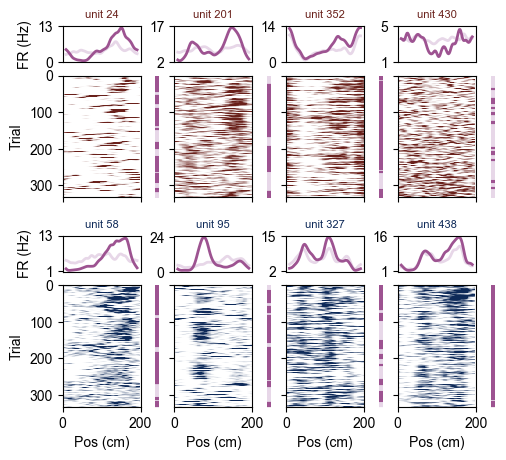

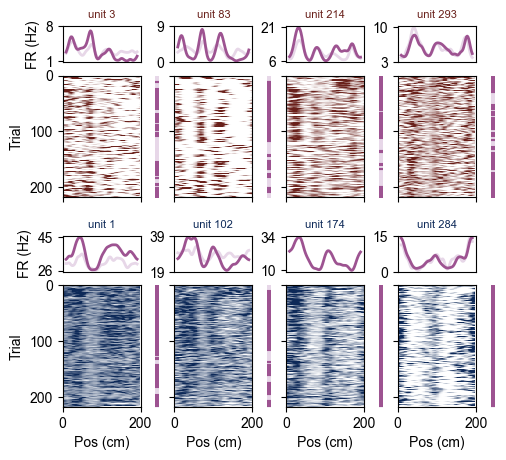

In [17]:
# Keys: (mouse, day), values: list of cluster_ids to plot
# give 4 example grid cells from each shank and 4 ngs cells from each shank for 2 mouse-days
example_cells = {
    (26, 19): [24, 201, 352, 430, 58, 95, 327, 438],
    (25, 25): [3, 83, 214, 293, 1, 102, 174, 284],
}

# --- Plot WITHOUT speed column ---
for (mouse, day), cluster_ids in example_cells.items():
    gcs, ngs, all = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]

    gc_ids = set(gcs.cluster_id.values)
    cluster_labels = [f'unit {cid}' for cid in cluster_ids]
    cluster_colors = ['#69201a' if cid in gc_ids else '#0d2958' for cid in cluster_ids]

    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_cols = n_cells 
    width_ratios = [w for _ in range(n_cols//2) for w in [1, 0.1]]

    fig, axes = plt.subplots(
        nrows=5, ncols=n_cols,
        figsize=(rm_figsize[0] * 5.6, rm_figsize[1] * 1.7 * 2),
        gridspec_kw={'height_ratios': [0.3, 1, 0.1, 0.3, 1], 'width_ratios': width_ratios},
    )

    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        if i >= n_cells//2:
            i = i - n_cells//2
            j = 3
        else:
            j = 0

        col_main = i * 2
        col_scatter = i * 2 + 1

        ax_avg = axes[j, col_main]
        ax_rate = axes[j+1, col_main]
        ax_scatter = axes[j+1, col_scatter]
        axes[j, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc}
        tcs_to_use[1000] = tc
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3]
        S = spectrograms.mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8","#9d5391"]):
            mask = (labels_ta == label_val)
            if np.sum(mask) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=8, color=color)
        ax_avg.set_xticks([])

        # FR(Hz) y axis: floor(min) and ceil(max) of plotted traces
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            fr_min = int(np.floor(np.nanmin(all_y)))
            fr_max = int(np.ceil(np.nanmax(all_y)))
            ax_avg.set_yticks([fr_min, fr_max])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                    extent=[*ax_rate.get_xlim(), ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]), ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')

        for label_val, plot_color in zip([False, True], ["#e7d7e8","#9d5391"]):
            mask = (labels_ta == label_val)
            ax_scatter.scatter(
                np.zeros(np.sum(mask)),
                np.arange(len(labels_ta))[mask],
                color=plot_color, rasterized=True, s=5, marker="_",
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        if i >= n_cells//2:
            i = i - n_cells//2
            j = 3
        else:            
            j = 0

        col = (i*2)+1
        axes[1+j, col].set_ylim(0, len(labels_ta))
        axes[1+j, col].invert_yaxis()
        col = i*2
        if i != 0:
            axes[1+j, col].set_yticklabels([])

    for i in range(n_cols):
        axes[2,i].axis('off')
        axes[1,i].set_xlabel('')  # Remove x label from the first row of cells
        axes[1,i].set_xticklabels([])

    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')
    axes[3, 0].set_ylabel('FR (Hz)')
    axes[4, 0].set_ylabel('Trial')
    plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
    plt.savefig(f'M{mouse}D{day}example_rate_maps_multishank.pdf')
    plt.show()


Processing Mouse 26 Day 19...
47 GCS cells, 213 NGS cells, 280 total cells


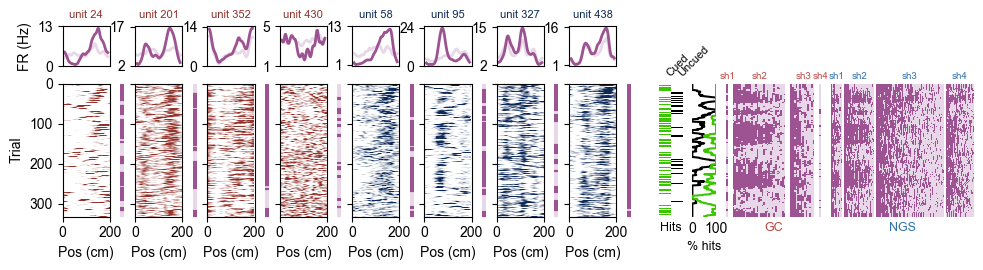

Processing Mouse 25 Day 25...
44 GCS cells, 49 NGS cells, 108 total cells


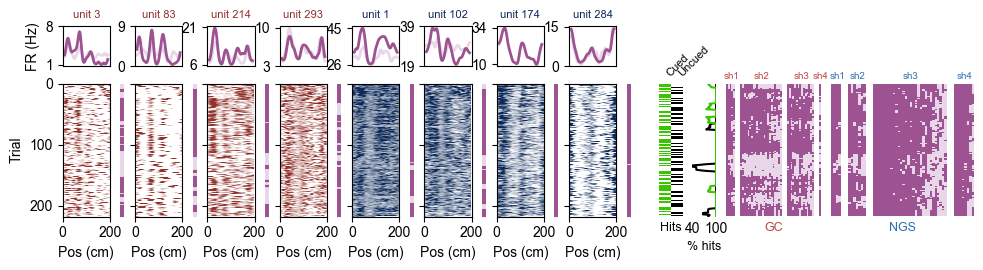

In [19]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

ngs_color = "#3171ae"
gc_color  = "#c04744"

mice = [26, 
        25] 
days = [19, 
        25]
example_cluster_ids = [[24, 201, 352, 430, 58, 95, 327, 438],
                       [3, 83, 214, 293, 1, 102, 174, 284]]
example_cluster_labels = [['unit 24', 'unit 201', 'unit 352', 'unit 430', 'unit 58', 'unit 95', 'unit 327', 'unit 438'],
                           ['unit 3', 'unit 83', 'unit 214', 'unit 293', 'unit 1', 'unit 102', 'unit 174', 'unit 284']]
example_cluster_colors = [['#90312a', '#90312a', '#90312a', '#90312a', ngs_color_dark, ngs_color_dark, ngs_color_dark, ngs_color_dark],
                           ['#90312a', '#90312a', '#90312a', '#90312a', ngs_color_dark, ngs_color_dark, ngs_color_dark, ngs_color_dark]]

for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(
    mice, days, example_cluster_ids, example_cluster_labels, example_cluster_colors
):
    print(f"Processing Mouse {mouse} Day {day}...")
    gcs, ngs, all_cells = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]
    print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all_cells)} total cells')

    # ---- GCS raster prep ----
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
    gc_shank_ids = sorted(gcs['shank_id'].unique())
    gcs_labels_list, gcs_shank_order = [], []
    for shank in gc_shank_ids:
        for cluster_id in gcs[gcs['shank_id'] == shank].cluster_id.values:
            try:
                tc = tcs[cluster_id] if cluster_id in tcs else None
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]
                tcs_to_use = {cluster_id: tc, 1000: tc}
                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                S = results[3].mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                gcs_labels_list.append(labels)
                gcs_shank_order.append(shank)
            except Exception as e:
                print(f"Error processing GCS cluster {cluster_id}: {e}")

    # Sort GCS by shank then by task-anchored sum descending
    gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels_list])
    gcs_shank_arr  = np.array(gcs_shank_order)
    gc_order = []
    for shank in gc_shank_ids:
        shank_indices = np.where(gcs_shank_arr == shank)[0]
        gc_order.extend(shank_indices[np.argsort(-gcs_label_sums[shank_indices])].tolist())
    gcs_labels_list = [gcs_labels_list[i] for i in gc_order]
    gcs_shank_order = [gcs_shank_order[i] for i in gc_order]

    # ---- NGS raster prep ----
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    shank_ids = sorted(ngs['shank_id'].unique())
    global_cell_list, global_shank_list = [], []
    for shank in shank_ids:
        for cid in ngs[ngs['shank_id'] == shank].cluster_id.values:
            global_cell_list.append(cid)
            global_shank_list.append(shank)

    all_labels_list, cell_shank_order = [], []
    for target_cluster_id, shank in zip(global_cell_list, global_shank_list):
        try:
            tc = tcs[target_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            tcs_to_use = {target_cluster_id: tc, 1000: tc}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
            labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
        except Exception as e:
            print(f"Error processing NGS cluster {target_cluster_id}: {e}")
            labels = np.full(last_ephys_bin, np.nan)
        all_labels_list.append(labels)
        cell_shank_order.append(shank)

    # Sort NGS within each shank by task-anchored sum descending
    shank_arr  = np.array(cell_shank_order)
    label_sums = np.array([np.nansum(lab == 1) for lab in all_labels_list])
    order = []
    for shank in shank_ids:
        shank_indices = np.where(shank_arr == shank)[0]
        order.extend(shank_indices[np.argsort(-label_sums[shank_indices])].tolist())
    order = np.array(order)

    max_len = max(
        [len(lab) for lab in all_labels_list] + [len(lab) for lab in gcs_labels_list]
    )

    # Build GCS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    gc_blocks = []
    for shank in gc_shank_ids:
        block = [gcs_labels_list[i] for i in range(len(gcs_labels_list)) if gcs_shank_order[i] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        gc_blocks.append(bm)
    labels_matrix_gcs = gc_blocks[0]
    for blk in gc_blocks[1:]:
        labels_matrix_gcs = np.vstack([labels_matrix_gcs, np.full((3, max_len), np.nan), blk])

    # Build NGS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    ngs_blocks = []
    for shank in shank_ids:
        block = [all_labels_list[idx] for idx in order if cell_shank_order[idx] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        ngs_blocks.append(bm)
    labels_matrix_ngs = ngs_blocks[0]
    for blk in ngs_blocks[1:]:
        labels_matrix_ngs = np.vstack([labels_matrix_ngs, np.full((3, max_len), np.nan), blk])

    # ---- Hits raster ----
    nb_hit_mask = make_hit_mask(beh, 'nb')
    b_hit_mask  = make_hit_mask(beh, 'b')
    n_trials_beh = len(nb_hit_mask)
    n_use = min(max_len, n_trials_beh)
    hit_raster = np.full((2, max_len), np.nan)
    hit_raster[0, :n_use][b_hit_mask[:n_use]]  = 1
    hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1
    hit_cmap = ListedColormap(["white", "#3bc500", "black"])
    hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)
    hit_raster_plot = np.zeros_like(hit_raster)
    hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
    hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

    # ---- Rolling hit rate ----
    window = 10
    kernel = np.ones(window) / window
    nb_type_mask = make_trialtype_mask(beh, 'nb')
    b_type_mask  = make_trialtype_mask(beh, 'b')
    nb_num = np.convolve(nb_hit_mask.astype(float), kernel, mode='same')
    nb_den = np.convolve(nb_type_mask.astype(float), kernel, mode='same')
    b_num  = np.convolve(b_hit_mask.astype(float),  kernel, mode='same')
    b_den  = np.convolve(b_type_mask.astype(float), kernel, mode='same')
    nb_rolling = np.where(nb_den > 0, nb_num / nb_den * 100, np.nan)
    b_rolling  = np.where(b_den  > 0, b_num  / b_den  * 100, np.nan)
    nb_rolling_full = np.full(max_len, np.nan)
    b_rolling_full  = np.full(max_len, np.nan)
    nb_rolling_full[:n_use] = nb_rolling[:n_use]
    b_rolling_full[:n_use]  = b_rolling[:n_use]

    # ---- Figure layout ----
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_main_cols = 2 * n_cells
    main_width_ratios = [w for _ in range(n_cells) for w in [1, 0.1]]

    # Extra column widths: spacer + hits + pct + gcs + ngs
    n_gc_cells = labels_matrix_gcs.shape[0]
    n_ngs_cells = labels_matrix_ngs.shape[0]
    extra_widths = [0.15, 0.5, 0.5, 2, 3]
    n_total_cols = n_main_cols + 5

    fig = plt.figure(figsize=(rm_figsize[0] * (5.6 + sum(extra_widths)), rm_figsize[1] * 1.7))
    gs = mgridspec.GridSpec(
        2, n_total_cols,
        height_ratios=[0.3, 1],
        width_ratios=main_width_ratios + extra_widths,
        figure=fig, wspace=0.3, hspace=0.2,
    )

    # Main 2 × n_main_cols axes
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(n_main_cols)] for r in range(2)])

    # Spacer column — row 1, axes off
    ax_spacer = fig.add_subplot(gs[1, n_main_cols])
    ax_spacer.axis('off')

    # 4 extra axes — row 1 only, matching the height of the trial/rate map row
    ax_hits = fig.add_subplot(gs[1, n_main_cols + 1])
    ax_pct  = fig.add_subplot(gs[1, n_main_cols + 2])
    ax_gcs  = fig.add_subplot(gs[1, n_main_cols + 3])
    ax_ngs  = fig.add_subplot(gs[1, n_main_cols + 4])

    # Hide the row-0 cells above the spacer and 4 extra columns
    for col_offset in range(5):
        fig.add_subplot(gs[0, n_main_cols + col_offset]).axis('off')

    # ---- Populate main cell plots ----
    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        col_main    = 2 * i
        col_scatter = 2 * i + 1
        ax_avg     = axes[0, col_main]
        ax_rate    = axes[1, col_main]
        ax_scatter = axes[1, col_scatter]
        axes[0, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc, 1000: tc}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        S = results[3].mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            if mask.sum() > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=8, color=color)
        ax_avg.set_xticks([])
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            ax_avg.set_yticks([int(np.floor(np.nanmin(all_y))), int(np.ceil(np.nanmax(all_y)))])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                       extent=[*ax_rate.get_xlim(),
                                ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                                ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            ax_scatter.scatter(
                np.zeros(mask.sum()), np.where(mask)[0],
                color=plot_color, rasterized=True, s=5, marker='_',
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        axes[1, i * 2 + 1].set_ylim(0, len(labels_ta))
        axes[1, i * 2 + 1].invert_yaxis()
        if i != 0:
            axes[1, i * 2].set_yticklabels([])
    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')

    trial_ylim = (max_len, 0)  # inverted: 0 at top, max_len at bottom

    # ---- Hits raster column: transposed so trials run vertically ----
    # hit_raster_plot shape: (2, max_len) → transpose to (max_len, 2)
    ax_hits.imshow(hit_raster_plot.T, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                   interpolation='nearest', rasterized=False,
                   extent=[-0.5, 1.5, max_len - 0.5, -0.5], origin='upper')
    ax_hits.set_xticks([0, 1])
    ax_hits.xaxis.tick_top()
    ax_hits.set_xticklabels(['Cued', 'Uncued'], fontsize=8, rotation=45, ha='left')
    ax_hits.set_yticks([])
    ax_hits.set_ylim(*trial_ylim)
    ax_hits.set_xlabel('Hits', fontsize=9)
    for spine in ax_hits.spines.values():
        spine.set_visible(False)
    ax_hits.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, left=False, labelleft=False, length=0)

    # ---- % hits column: x=%, y=trial ----
    trial_axis = np.arange(max_len)
    ax_pct.plot(nb_rolling_full, trial_axis, color='black', label='NB')
    ax_pct.plot(b_rolling_full,  trial_axis, color='#3bc500', label='B')
    ax_pct.set_xlabel('% hits', fontsize=9)
    ax_pct.set_yticks([])
    ax_pct.set_ylim(*trial_ylim)
    y_all = np.concatenate([nb_rolling_full, b_rolling_full])
    finite = np.isfinite(y_all)
    if finite.any():
        x_min, x_max = y_all[finite].min(), y_all[finite].max()
        if x_min == x_max:
            margin = 0.05 * max(abs(x_min), 1.0)
            x_min -= margin; x_max += margin
    else:
        x_min, x_max = 0.0, 100.0
    ax_pct.set_xlim(x_min, x_max)
    ax_pct.set_xticks(np.linspace(x_min, x_max, 2))
    for spine in ax_pct.spines.values():
        spine.set_visible(False)
    ax_pct.tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

    # ---- GCS raster column: transposed so trials run vertically ----
    # labels_matrix_gcs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_gc_cols = labels_matrix_gcs.shape[0]
    ax_gcs.imshow(labels_matrix_gcs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_gc_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_gcs.set_xlabel('GC', fontsize=9, color=gc_color)
    ax_gcs.set_xticks([])
    ax_gcs.set_yticks([])
    ax_gcs.set_ylim(*trial_ylim)
    for spine in ax_gcs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_gc = 0
    for blk, shank in zip(gc_blocks, gc_shank_ids):
        x_mid = x_gc + blk.shape[0] / 2
        ax_gcs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=gc_color, clip_on=False)
        x_gc += blk.shape[0] + 3

    # ---- NGS raster column: transposed so trials run vertically ----
    # labels_matrix_ngs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_ngs_cols = labels_matrix_ngs.shape[0]
    ax_ngs.imshow(labels_matrix_ngs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_ngs_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_ngs.set_xlabel('NGS', fontsize=9, color=ngs_color)
    ax_ngs.set_xticks([])
    ax_ngs.set_yticks([])
    ax_ngs.set_ylim(*trial_ylim)
    for spine in ax_ngs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_ngs = 0
    for blk, shank in zip(ngs_blocks, shank_ids):
        x_mid = x_ngs + blk.shape[0] / 2
        ax_ngs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=ngs_color, clip_on=False)
        x_ngs += blk.shape[0] + 3

    plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
    plt.savefig(f'M{mouse}D{day}example_rate_maps_multishank_v2.pdf')
    plt.show()


Processing Mouse 26 Day 19...
47 GCS cells, 213 NGS cells, 280 total cells


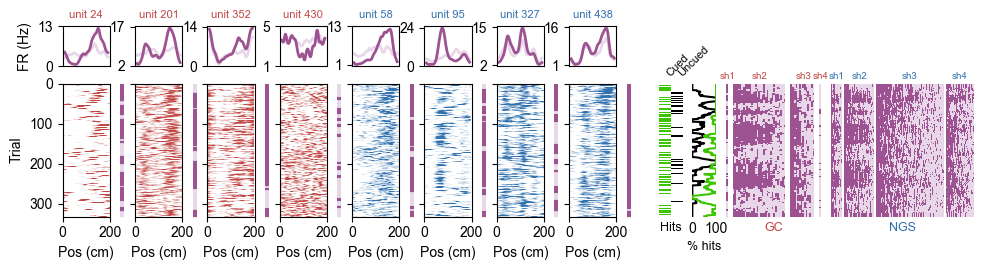

Processing Mouse 25 Day 25...
44 GCS cells, 49 NGS cells, 108 total cells


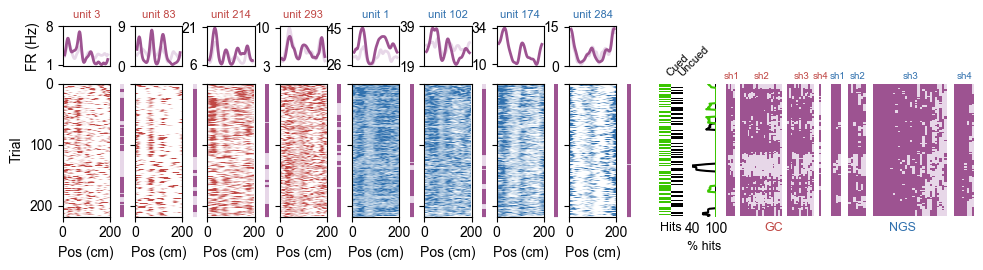

In [9]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

ngs_color = "#3171ae"
gc_color  = "#c04744"

mice = [26, 
        25] 
days = [19, 
        25]
example_cluster_ids = [[24, 201, 352, 430, 58, 95, 327, 438],
                       [3, 83, 214, 293, 1, 102, 174, 284]]
example_cluster_labels = [['unit 24', 'unit 201', 'unit 352', 'unit 430', 'unit 58', 'unit 95', 'unit 327', 'unit 438'],
                           ['unit 3', 'unit 83', 'unit 214', 'unit 293', 'unit 1', 'unit 102', 'unit 174', 'unit 284']]
example_cluster_colors = [[gc_color, gc_color, gc_color, gc_color, ngs_color, ngs_color, ngs_color, ngs_color],
                          [gc_color, gc_color, gc_color, gc_color, ngs_color, ngs_color, ngs_color, ngs_color]]

for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(
    mice, days, example_cluster_ids, example_cluster_labels, example_cluster_colors
):
    print(f"Processing Mouse {mouse} Day {day}...")
    gcs, ngs, all_cells = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]
    print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all_cells)} total cells')

    # ---- GCS raster prep ----
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
    gc_shank_ids = sorted(gcs['shank_id'].unique())
    gcs_labels_list, gcs_shank_order = [], []
    for shank in gc_shank_ids:
        for cluster_id in gcs[gcs['shank_id'] == shank].cluster_id.values:
            try:
                tc = tcs[cluster_id] if cluster_id in tcs else None
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]
                tcs_to_use = {cluster_id: tc, 1000: tc}
                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                S = results[3].mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                gcs_labels_list.append(labels)
                gcs_shank_order.append(shank)
            except Exception as e:
                print(f"Error processing GCS cluster {cluster_id}: {e}")

    # Sort GCS by shank then by task-anchored sum descending
    gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels_list])
    gcs_shank_arr  = np.array(gcs_shank_order)
    gc_order = []
    for shank in gc_shank_ids:
        shank_indices = np.where(gcs_shank_arr == shank)[0]
        gc_order.extend(shank_indices[np.argsort(-gcs_label_sums[shank_indices])].tolist())
    gcs_labels_list = [gcs_labels_list[i] for i in gc_order]
    gcs_shank_order = [gcs_shank_order[i] for i in gc_order]

    # ---- NGS raster prep ----
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    shank_ids = sorted(ngs['shank_id'].unique())
    global_cell_list, global_shank_list = [], []
    for shank in shank_ids:
        for cid in ngs[ngs['shank_id'] == shank].cluster_id.values:
            global_cell_list.append(cid)
            global_shank_list.append(shank)

    all_labels_list, cell_shank_order = [], []
    for target_cluster_id, shank in zip(global_cell_list, global_shank_list):
        try:
            tc = tcs[target_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            tcs_to_use = {target_cluster_id: tc, 1000: tc}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
            labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
        except Exception as e:
            print(f"Error processing NGS cluster {target_cluster_id}: {e}")
            labels = np.full(last_ephys_bin, np.nan)
        all_labels_list.append(labels)
        cell_shank_order.append(shank)

    # Sort NGS within each shank by task-anchored sum descending
    shank_arr  = np.array(cell_shank_order)
    label_sums = np.array([np.nansum(lab == 1) for lab in all_labels_list])
    order = []
    for shank in shank_ids:
        shank_indices = np.where(shank_arr == shank)[0]
        order.extend(shank_indices[np.argsort(-label_sums[shank_indices])].tolist())
    order = np.array(order)

    max_len = max(
        [len(lab) for lab in all_labels_list] + [len(lab) for lab in gcs_labels_list]
    )

    # Build GCS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    gc_blocks = []
    for shank in gc_shank_ids:
        block = [gcs_labels_list[i] for i in range(len(gcs_labels_list)) if gcs_shank_order[i] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        gc_blocks.append(bm)
    labels_matrix_gcs = gc_blocks[0]
    for blk in gc_blocks[1:]:
        labels_matrix_gcs = np.vstack([labels_matrix_gcs, np.full((3, max_len), np.nan), blk])

    # Build NGS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    ngs_blocks = []
    for shank in shank_ids:
        block = [all_labels_list[idx] for idx in order if cell_shank_order[idx] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        ngs_blocks.append(bm)
    labels_matrix_ngs = ngs_blocks[0]
    for blk in ngs_blocks[1:]:
        labels_matrix_ngs = np.vstack([labels_matrix_ngs, np.full((3, max_len), np.nan), blk])

    # ---- Hits raster ----
    nb_hit_mask = make_hit_mask(beh, 'nb')
    b_hit_mask  = make_hit_mask(beh, 'b')
    n_trials_beh = len(nb_hit_mask)
    n_use = min(max_len, n_trials_beh)
    hit_raster = np.full((2, max_len), np.nan)
    hit_raster[0, :n_use][b_hit_mask[:n_use]]  = 1
    hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1
    hit_cmap = ListedColormap(["white", "#3bc500", "black"])
    hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)
    hit_raster_plot = np.zeros_like(hit_raster)
    hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
    hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

    # ---- Rolling hit rate ----
    window = 10
    kernel = np.ones(window) / window
    nb_type_mask = make_trialtype_mask(beh, 'nb')
    b_type_mask  = make_trialtype_mask(beh, 'b')
    nb_num = np.convolve(nb_hit_mask.astype(float), kernel, mode='same')
    nb_den = np.convolve(nb_type_mask.astype(float), kernel, mode='same')
    b_num  = np.convolve(b_hit_mask.astype(float),  kernel, mode='same')
    b_den  = np.convolve(b_type_mask.astype(float), kernel, mode='same')
    nb_rolling = np.where(nb_den > 0, nb_num / nb_den * 100, np.nan)
    b_rolling  = np.where(b_den  > 0, b_num  / b_den  * 100, np.nan)
    nb_rolling_full = np.full(max_len, np.nan)
    b_rolling_full  = np.full(max_len, np.nan)
    nb_rolling_full[:n_use] = nb_rolling[:n_use]
    b_rolling_full[:n_use]  = b_rolling[:n_use]

    # ---- Figure layout ----
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_main_cols = 2 * n_cells
    main_width_ratios = [w for _ in range(n_cells) for w in [1, 0.1]]

    # Extra column widths: spacer + hits + pct + gcs + ngs
    n_gc_cells = labels_matrix_gcs.shape[0]
    n_ngs_cells = labels_matrix_ngs.shape[0]
    extra_widths = [0.15, 0.5, 0.5, 2, 3]
    n_total_cols = n_main_cols + 5

    fig = plt.figure(figsize=(rm_figsize[0] * (5.6 + sum(extra_widths)), rm_figsize[1] * 1.7))
    gs = mgridspec.GridSpec(
        2, n_total_cols,
        height_ratios=[0.3, 1],
        width_ratios=main_width_ratios + extra_widths,
        figure=fig, wspace=0.3, hspace=0.2,
    )

    # Main 2 × n_main_cols axes
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(n_main_cols)] for r in range(2)])

    # Spacer column — row 1, axes off
    ax_spacer = fig.add_subplot(gs[1, n_main_cols])
    ax_spacer.axis('off')

    # 4 extra axes — row 1 only, matching the height of the trial/rate map row
    ax_hits = fig.add_subplot(gs[1, n_main_cols + 1])
    ax_pct  = fig.add_subplot(gs[1, n_main_cols + 2])
    ax_gcs  = fig.add_subplot(gs[1, n_main_cols + 3])
    ax_ngs  = fig.add_subplot(gs[1, n_main_cols + 4])

    # Hide the row-0 cells above the spacer and 4 extra columns
    for col_offset in range(5):
        fig.add_subplot(gs[0, n_main_cols + col_offset]).axis('off')

    # ---- Populate main cell plots ----
    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        col_main    = 2 * i
        col_scatter = 2 * i + 1
        ax_avg     = axes[0, col_main]
        ax_rate    = axes[1, col_main]
        ax_scatter = axes[1, col_scatter]
        axes[0, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc, 1000: tc}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        S = results[3].mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            if mask.sum() > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=8, color=color)
        ax_avg.set_xticks([])
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            ax_avg.set_yticks([int(np.floor(np.nanmin(all_y))), int(np.ceil(np.nanmax(all_y)))])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                       extent=[*ax_rate.get_xlim(),
                                ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                                ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            ax_scatter.scatter(
                np.zeros(mask.sum()), np.where(mask)[0],
                color=plot_color, rasterized=True, s=5, marker='_',
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        axes[1, i * 2 + 1].set_ylim(0, len(labels_ta))
        axes[1, i * 2 + 1].invert_yaxis()
        if i != 0:
            axes[1, i * 2].set_yticklabels([])
    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')

    trial_ylim = (max_len, 0)  # inverted: 0 at top, max_len at bottom

    # ---- Hits raster column: transposed so trials run vertically ----
    # hit_raster_plot shape: (2, max_len) → transpose to (max_len, 2)
    ax_hits.imshow(hit_raster_plot.T, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                   interpolation='nearest', rasterized=False,
                   extent=[-0.5, 1.5, max_len - 0.5, -0.5], origin='upper')
    ax_hits.set_xticks([0, 1])
    ax_hits.xaxis.tick_top()
    ax_hits.set_xticklabels(['Cued', 'Uncued'], fontsize=8, rotation=45, ha='left')
    ax_hits.set_yticks([])
    ax_hits.set_ylim(*trial_ylim)
    ax_hits.set_xlabel('Hits', fontsize=9)
    for spine in ax_hits.spines.values():
        spine.set_visible(False)
    ax_hits.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, left=False, labelleft=False, length=0)

    # ---- % hits column: x=%, y=trial ----
    trial_axis = np.arange(max_len)
    ax_pct.plot(nb_rolling_full, trial_axis, color='black', label='NB')
    ax_pct.plot(b_rolling_full,  trial_axis, color='#3bc500', label='B')
    ax_pct.set_xlabel('% hits', fontsize=9)
    ax_pct.set_yticks([])
    ax_pct.set_ylim(*trial_ylim)
    y_all = np.concatenate([nb_rolling_full, b_rolling_full])
    finite = np.isfinite(y_all)
    if finite.any():
        x_min, x_max = y_all[finite].min(), y_all[finite].max()
        if x_min == x_max:
            margin = 0.05 * max(abs(x_min), 1.0)
            x_min -= margin; x_max += margin
    else:
        x_min, x_max = 0.0, 100.0
    ax_pct.set_xlim(x_min, x_max)
    ax_pct.set_xticks(np.linspace(x_min, x_max, 2))
    for spine in ax_pct.spines.values():
        spine.set_visible(False)
    ax_pct.tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

    # ---- GCS raster column: transposed so trials run vertically ----
    # labels_matrix_gcs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_gc_cols = labels_matrix_gcs.shape[0]
    ax_gcs.imshow(labels_matrix_gcs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_gc_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_gcs.set_xlabel('GC', fontsize=9, color=gc_color)
    ax_gcs.set_xticks([])
    ax_gcs.set_yticks([])
    ax_gcs.set_ylim(*trial_ylim)
    for spine in ax_gcs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_gc = 0
    for blk, shank in zip(gc_blocks, gc_shank_ids):
        x_mid = x_gc + blk.shape[0] / 2
        ax_gcs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=gc_color, clip_on=False)
        x_gc += blk.shape[0] + 3

    # ---- NGS raster column: transposed so trials run vertically ----
    # labels_matrix_ngs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_ngs_cols = labels_matrix_ngs.shape[0]
    ax_ngs.imshow(labels_matrix_ngs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_ngs_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_ngs.set_xlabel('NGS', fontsize=9, color=ngs_color)
    ax_ngs.set_xticks([])
    ax_ngs.set_yticks([])
    ax_ngs.set_ylim(*trial_ylim)
    for spine in ax_ngs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_ngs = 0
    for blk, shank in zip(ngs_blocks, shank_ids):
        x_mid = x_ngs + blk.shape[0] / 2
        ax_ngs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=ngs_color, clip_on=False)
        x_ngs += blk.shape[0] + 3

    plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
    plt.savefig(f'M{mouse}D{day}example_rate_maps_multishank_v3.pdf')
    plt.show()


Processing Mouse 26 Day 19...
47 GCS cells, 213 NGS cells, 280 total cells


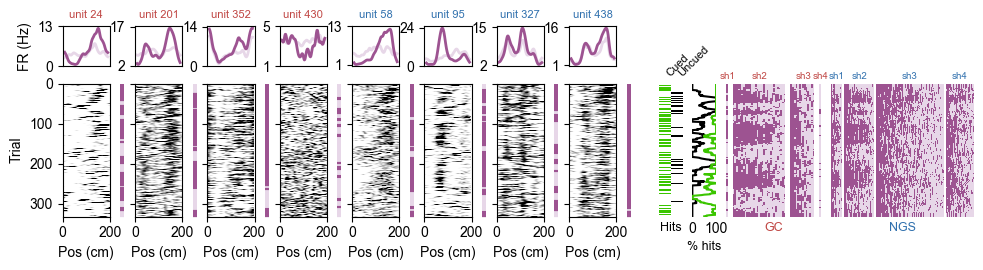

Processing Mouse 25 Day 25...
44 GCS cells, 49 NGS cells, 108 total cells


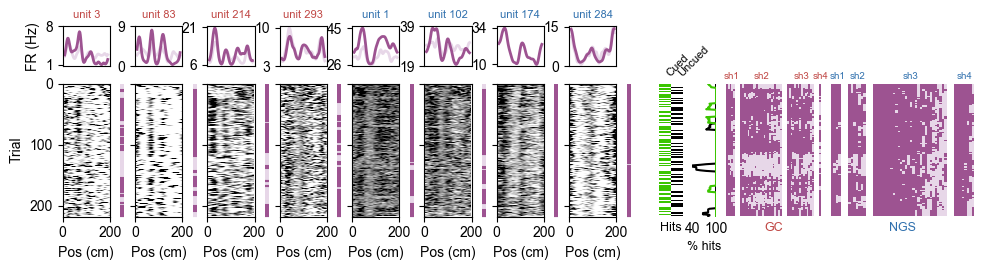

In [10]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

ngs_color = "#3171ae"
gc_color  = "#c04744"

mice = [26, 
        25] 
days = [19, 
        25]
example_cluster_ids = [[24, 201, 352, 430, 58, 95, 327, 438],
                       [3, 83, 214, 293, 1, 102, 174, 284]]
example_cluster_labels = [['unit 24', 'unit 201', 'unit 352', 'unit 430', 'unit 58', 'unit 95', 'unit 327', 'unit 438'],
                           ['unit 3', 'unit 83', 'unit 214', 'unit 293', 'unit 1', 'unit 102', 'unit 174', 'unit 284']]
example_cluster_colors = [[gc_color, gc_color, gc_color, gc_color, ngs_color, ngs_color, ngs_color, ngs_color],
                          [gc_color, gc_color, gc_color, gc_color, ngs_color, ngs_color, ngs_color, ngs_color]]

for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(
    mice, days, example_cluster_ids, example_cluster_labels, example_cluster_colors
):
    print(f"Processing Mouse {mouse} Day {day}...")
    gcs, ngs, all_cells = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]
    print(f'{len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all_cells)} total cells')

    # ---- GCS raster prep ----
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
    gc_shank_ids = sorted(gcs['shank_id'].unique())
    gcs_labels_list, gcs_shank_order = [], []
    for shank in gc_shank_ids:
        for cluster_id in gcs[gcs['shank_id'] == shank].cluster_id.values:
            try:
                tc = tcs[cluster_id] if cluster_id in tcs else None
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]
                tcs_to_use = {cluster_id: tc, 1000: tc}
                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                S = results[3].mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
                gcs_labels_list.append(labels)
                gcs_shank_order.append(shank)
            except Exception as e:
                print(f"Error processing GCS cluster {cluster_id}: {e}")

    # Sort GCS by shank then by task-anchored sum descending
    gcs_label_sums = np.array([np.nansum(lab == 1) for lab in gcs_labels_list])
    gcs_shank_arr  = np.array(gcs_shank_order)
    gc_order = []
    for shank in gc_shank_ids:
        shank_indices = np.where(gcs_shank_arr == shank)[0]
        gc_order.extend(shank_indices[np.argsort(-gcs_label_sums[shank_indices])].tolist())
    gcs_labels_list = [gcs_labels_list[i] for i in gc_order]
    gcs_shank_order = [gcs_shank_order[i] for i in gc_order]

    # ---- NGS raster prep ----
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    shank_ids = sorted(ngs['shank_id'].unique())
    global_cell_list, global_shank_list = [], []
    for shank in shank_ids:
        for cid in ngs[ngs['shank_id'] == shank].cluster_id.values:
            global_cell_list.append(cid)
            global_shank_list.append(shank)

    all_labels_list, cell_shank_order = [], []
    for target_cluster_id, shank in zip(global_cell_list, global_shank_list):
        try:
            tc = tcs[target_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            tcs_to_use = {target_cluster_id: tc, 1000: tc}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
            labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)
        except Exception as e:
            print(f"Error processing NGS cluster {target_cluster_id}: {e}")
            labels = np.full(last_ephys_bin, np.nan)
        all_labels_list.append(labels)
        cell_shank_order.append(shank)

    # Sort NGS within each shank by task-anchored sum descending
    shank_arr  = np.array(cell_shank_order)
    label_sums = np.array([np.nansum(lab == 1) for lab in all_labels_list])
    order = []
    for shank in shank_ids:
        shank_indices = np.where(shank_arr == shank)[0]
        order.extend(shank_indices[np.argsort(-label_sums[shank_indices])].tolist())
    order = np.array(order)

    max_len = max(
        [len(lab) for lab in all_labels_list] + [len(lab) for lab in gcs_labels_list]
    )

    # Build GCS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    gc_blocks = []
    for shank in gc_shank_ids:
        block = [gcs_labels_list[i] for i in range(len(gcs_labels_list)) if gcs_shank_order[i] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        gc_blocks.append(bm)
    labels_matrix_gcs = gc_blocks[0]
    for blk in gc_blocks[1:]:
        labels_matrix_gcs = np.vstack([labels_matrix_gcs, np.full((3, max_len), np.nan), blk])

    # Build NGS matrix with 3 blank rows between shanks (shape: n_cells × max_len)
    ngs_blocks = []
    for shank in shank_ids:
        block = [all_labels_list[idx] for idx in order if cell_shank_order[idx] == shank]
        bm = np.full((len(block), max_len), np.nan)
        for i, lab in enumerate(block):
            bm[i, :len(lab)] = lab
        ngs_blocks.append(bm)
    labels_matrix_ngs = ngs_blocks[0]
    for blk in ngs_blocks[1:]:
        labels_matrix_ngs = np.vstack([labels_matrix_ngs, np.full((3, max_len), np.nan), blk])

    # ---- Hits raster ----
    nb_hit_mask = make_hit_mask(beh, 'nb')
    b_hit_mask  = make_hit_mask(beh, 'b')
    n_trials_beh = len(nb_hit_mask)
    n_use = min(max_len, n_trials_beh)
    hit_raster = np.full((2, max_len), np.nan)
    hit_raster[0, :n_use][b_hit_mask[:n_use]]  = 1
    hit_raster[1, :n_use][nb_hit_mask[:n_use]] = 1
    hit_cmap = ListedColormap(["white", "#3bc500", "black"])
    hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)
    hit_raster_plot = np.zeros_like(hit_raster)
    hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
    hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

    # ---- Rolling hit rate ----
    window = 10
    kernel = np.ones(window) / window
    nb_type_mask = make_trialtype_mask(beh, 'nb')
    b_type_mask  = make_trialtype_mask(beh, 'b')
    nb_num = np.convolve(nb_hit_mask.astype(float), kernel, mode='same')
    nb_den = np.convolve(nb_type_mask.astype(float), kernel, mode='same')
    b_num  = np.convolve(b_hit_mask.astype(float),  kernel, mode='same')
    b_den  = np.convolve(b_type_mask.astype(float), kernel, mode='same')
    nb_rolling = np.where(nb_den > 0, nb_num / nb_den * 100, np.nan)
    b_rolling  = np.where(b_den  > 0, b_num  / b_den  * 100, np.nan)
    nb_rolling_full = np.full(max_len, np.nan)
    b_rolling_full  = np.full(max_len, np.nan)
    nb_rolling_full[:n_use] = nb_rolling[:n_use]
    b_rolling_full[:n_use]  = b_rolling[:n_use]

    # ---- Figure layout ----
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_main_cols = 2 * n_cells
    main_width_ratios = [w for _ in range(n_cells) for w in [1, 0.1]]

    # Extra column widths: spacer + hits + pct + gcs + ngs
    n_gc_cells = labels_matrix_gcs.shape[0]
    n_ngs_cells = labels_matrix_ngs.shape[0]
    extra_widths = [0.15, 0.5, 0.5, 2, 3]
    n_total_cols = n_main_cols + 5

    fig = plt.figure(figsize=(rm_figsize[0] * (5.6 + sum(extra_widths)), rm_figsize[1] * 1.7))
    gs = mgridspec.GridSpec(
        2, n_total_cols,
        height_ratios=[0.3, 1],
        width_ratios=main_width_ratios + extra_widths,
        figure=fig, wspace=0.3, hspace=0.2,
    )

    # Main 2 × n_main_cols axes
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(n_main_cols)] for r in range(2)])

    # Spacer column — row 1, axes off
    ax_spacer = fig.add_subplot(gs[1, n_main_cols])
    ax_spacer.axis('off')

    # 4 extra axes — row 1 only, matching the height of the trial/rate map row
    ax_hits = fig.add_subplot(gs[1, n_main_cols + 1])
    ax_pct  = fig.add_subplot(gs[1, n_main_cols + 2])
    ax_gcs  = fig.add_subplot(gs[1, n_main_cols + 3])
    ax_ngs  = fig.add_subplot(gs[1, n_main_cols + 4])

    # Hide the row-0 cells above the spacer and 4 extra columns
    for col_offset in range(5):
        fig.add_subplot(gs[0, n_main_cols + col_offset]).axis('off')

    # ---- Populate main cell plots ----
    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        col_main    = 2 * i
        col_scatter = 2 * i + 1
        ax_avg     = axes[0, col_main]
        ax_rate    = axes[1, col_main]
        ax_scatter = axes[1, col_scatter]
        axes[0, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc, 1000: tc}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        S = results[3].mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            if mask.sum() > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=8, color=color)
        ax_avg.set_xticks([])
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            ax_avg.set_yticks([int(np.floor(np.nanmin(all_y))), int(np.ceil(np.nanmax(all_y)))])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap("#000000"))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                       extent=[*ax_rate.get_xlim(),
                                ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]),
                                ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')
        for label_val, plot_color in zip([False, True], ["#e7d7e8", "#9d5391"]):
            mask = labels_ta == label_val
            ax_scatter.scatter(
                np.zeros(mask.sum()), np.where(mask)[0],
                color=plot_color, rasterized=True, s=5, marker='_',
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        axes[1, i * 2 + 1].set_ylim(0, len(labels_ta))
        axes[1, i * 2 + 1].invert_yaxis()
        if i != 0:
            axes[1, i * 2].set_yticklabels([])
    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')

    trial_ylim = (max_len, 0)  # inverted: 0 at top, max_len at bottom

    # ---- Hits raster column: transposed so trials run vertically ----
    # hit_raster_plot shape: (2, max_len) → transpose to (max_len, 2)
    ax_hits.imshow(hit_raster_plot.T, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                   interpolation='nearest', rasterized=False,
                   extent=[-0.5, 1.5, max_len - 0.5, -0.5], origin='upper')
    ax_hits.set_xticks([0, 1])
    ax_hits.xaxis.tick_top()
    ax_hits.set_xticklabels(['Cued', 'Uncued'], fontsize=8, rotation=45, ha='left')
    ax_hits.set_yticks([])
    ax_hits.set_ylim(*trial_ylim)
    ax_hits.set_xlabel('Hits', fontsize=9)
    for spine in ax_hits.spines.values():
        spine.set_visible(False)
    ax_hits.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, left=False, labelleft=False, length=0)

    # ---- % hits column: x=%, y=trial ----
    trial_axis = np.arange(max_len)
    ax_pct.plot(nb_rolling_full, trial_axis, color='black', label='NB')
    ax_pct.plot(b_rolling_full,  trial_axis, color='#3bc500', label='B')
    ax_pct.set_xlabel('% hits', fontsize=9)
    ax_pct.set_yticks([])
    ax_pct.set_ylim(*trial_ylim)
    y_all = np.concatenate([nb_rolling_full, b_rolling_full])
    finite = np.isfinite(y_all)
    if finite.any():
        x_min, x_max = y_all[finite].min(), y_all[finite].max()
        if x_min == x_max:
            margin = 0.05 * max(abs(x_min), 1.0)
            x_min -= margin; x_max += margin
    else:
        x_min, x_max = 0.0, 100.0
    ax_pct.set_xlim(x_min, x_max)
    ax_pct.set_xticks(np.linspace(x_min, x_max, 2))
    for spine in ax_pct.spines.values():
        spine.set_visible(False)
    ax_pct.tick_params(left=False, bottom=True, labelleft=False, labelbottom=True, length=0)

    # ---- GCS raster column: transposed so trials run vertically ----
    # labels_matrix_gcs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_gc_cols = labels_matrix_gcs.shape[0]
    ax_gcs.imshow(labels_matrix_gcs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_gc_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_gcs.set_xlabel('GC', fontsize=9, color=gc_color)
    ax_gcs.set_xticks([])
    ax_gcs.set_yticks([])
    ax_gcs.set_ylim(*trial_ylim)
    for spine in ax_gcs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_gc = 0
    for blk, shank in zip(gc_blocks, gc_shank_ids):
        x_mid = x_gc + blk.shape[0] / 2
        ax_gcs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=gc_color, clip_on=False)
        x_gc += blk.shape[0] + 3

    # ---- NGS raster column: transposed so trials run vertically ----
    # labels_matrix_ngs shape: (n_cells, max_len) → transpose to (max_len, n_cells)
    n_ngs_cols = labels_matrix_ngs.shape[0]
    ax_ngs.imshow(labels_matrix_ngs.T, aspect='auto', cmap=cmap, norm=norm,
                  interpolation='nearest', rasterized=False,
                  extent=[-0.5, n_ngs_cols - 0.5, max_len - 0.5, -0.5], origin='upper')
    ax_ngs.set_xlabel('NGS', fontsize=9, color=ngs_color)
    ax_ngs.set_xticks([])
    ax_ngs.set_yticks([])
    ax_ngs.set_ylim(*trial_ylim)
    for spine in ax_ngs.spines.values():
        spine.set_visible(False)
    # Shank labels at x midpoint of each block, above the plot
    x_ngs = 0
    for blk, shank in zip(ngs_blocks, shank_ids):
        x_mid = x_ngs + blk.shape[0] / 2
        ax_ngs.text(x_mid, -max_len * 0.02, f"sh{shank + 1}",
                    fontsize=7, va='bottom', ha='center', color=ngs_color, clip_on=False)
        x_ngs += blk.shape[0] + 3

    plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)
    plt.savefig(f'M{mouse}D{day}example_rate_maps_multishank_v4.pdf')
    plt.show()


In [ ]:
mice = [26, 
        25] 
days = [19, 
        25]
example_cluster_ids = [[201, 58, 95, 327, 438],
                       [83, 1, 102, 174, 284]]
example_cluster_labels = [['GCS', 'NGS', 'NGS', 'NGS', 'NGS'],
                          ['GCS', 'NGS', 'NGS', 'NGS', 'NGS']]
example_cluster_colors = [['#69201a', '#0d2958', '#0d2958', '#0d2958', '#0d2958'],
                          ['#69201a', '#0d2958', '#0d2958', '#0d2958', '#0d2958']]

# --- Plot WITHOUT speed column ---
for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(mice, days, 
                                                                   example_cluster_ids, 
                                                                   example_cluster_labels, 
                                                                   example_cluster_colors):
    gcs, ngs, all = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]

    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap = ListedColormap(["#e7d7e8", "#9d5391", "white"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2], cmap.N)

    n_cells = len(cluster_ids)
    n_cols = 2 * n_cells
    width_ratios = [w for _ in range(n_cells) for w in [1, 0.1]]

    fig, axes = plt.subplots(
        nrows=2, ncols=n_cols,
        figsize=(rm_figsize[0] * 5.6, rm_figsize[1] * 1.7),
        gridspec_kw={'height_ratios': [0.3, 1], 'width_ratios': width_ratios},
    )

    for i, (cell_id, label, color) in enumerate(zip(cluster_ids, cluster_labels, cluster_colors)):
        col_main = 2 * i
        col_scatter = 2 * i + 1

        ax_avg = axes[0, col_main]
        ax_rate = axes[1, col_main]
        ax_scatter = axes[1, col_scatter]
        axes[0, col_scatter].axis('off')

        tc = tcs[cell_id] if cell_id in tcs else None
        if tc is None:
            continue
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]
        tcs_to_use = {cell_id: tc}
        tcs_to_use[1000] = tc
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3]
        S = spectrograms.mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels_ta = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
        labels_ta = get_kmeans_spatial_labels(tc, labels_ta, bs=bs, tl=tl)
        avg_ys = []
        for label_val, plot_color in zip([False, True], ["#e7d7e8","#9d5391"]):
            mask = (labels_ta == label_val)
            if np.sum(mask) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=mask)
                ax_avg.plot(x, y, color=plot_color, linewidth=2)
                avg_ys.append(y)
        ax_avg.set_title(label, fontsize=8, color=color)
        ax_avg.set_xticks([])

        # FR(Hz) y axis: floor(min) and ceil(max) of plotted traces
        if avg_ys:
            all_y = np.concatenate(avg_ys)
            fr_min = int(np.floor(np.nanmin(all_y)))
            fr_max = int(np.ceil(np.nanmax(all_y)))
            ax_avg.set_yticks([fr_min, fr_max])

        plot_firing_rate_map(ax_rate, tc, bs=bs, tl=tl, p=95, sort_indices=None, cmap=white_to_hex_cmap(color))
        raster = np.expand_dims(labels_ta, axis=0)
        ax_rate.imshow(raster, aspect='auto', cmap=cmap, norm=norm, interpolation='none',
                    extent=[*ax_rate.get_xlim(), ax_rate.get_ylim()[0] - 0.15 * (ax_rate.get_ylim()[1] - ax_rate.get_ylim()[0]), ax_rate.get_ylim()[0]])
        ax_rate.set_xlabel('Pos (cm)')

        for label_val, plot_color in zip([False, True], ["#e7d7e8","#9d5391"]):
            mask = (labels_ta == label_val)
            ax_scatter.scatter(
                np.zeros(np.sum(mask)),
                np.arange(len(labels_ta))[mask],
                color=plot_color, rasterized=True, s=5, marker="_",
            )
        ax_scatter.axis('off')

    for i in range(n_cells):
        col = (i*2)+1
        axes[1, col].set_ylim(0, len(labels_ta))
        axes[1, col].invert_yaxis()
        col = i*2
        if i != 0:
            axes[1, col].set_yticklabels([])

    axes[0, 0].set_ylabel('FR (Hz)')
    axes[1, 0].set_ylabel('Trial')
    plt.subplots_adjust(wspace=0.3, hspace=0.2, bottom=0.18)  # increase bottom margin
    plt.savefig(f'M{mouse}D{day}example_rate_maps_multishank.pdf')
    plt.show()


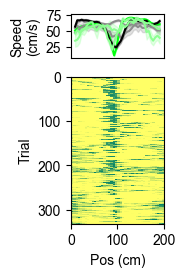

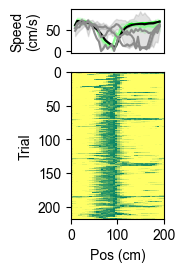

In [9]:
# --- Speed column only (same height as rate map plot) ---
import matplotlib.colors as mc

def lighten_color(color, factor=0.4):
    """Blend color toward white by factor (0=unchanged, 1=white)."""
    rgb = mc.to_rgb(color)
    return tuple(1 - (1 - factor) * (1 - c) for c in rgb)

for mouse, day, cluster_ids, cluster_labels, cluster_colors in zip(mice, days,
                                                                   example_cluster_ids,
                                                                   example_cluster_labels,
                                                                   example_cluster_colors):
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )

    speed_matrix, trial_type_colors, trial_order, pos_bins = get_heatmap_and_colors(
        beh, last_ephys_bin, tl, bs, sort=False
    )
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2

    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    trial_types_order = [trial_df.loc[int(ti), 'type'] for ti in trial_order]
    trial_perfs_order = [trial_df.loc[int(ti), 'performance'] for ti in trial_order]
    type_perf_groups = {}
    for i, (tt, perf) in enumerate(zip(trial_types_order, trial_perfs_order)):
        if str(tt) == 'nan':
            continue
        type_perf_groups.setdefault((tt, perf), []).append(i)

    fig, axes = plt.subplots(
        nrows=2, ncols=1,
        figsize=(rm_figsize[0] * 1.2, rm_figsize[1] * 1.7),
        gridspec_kw={'height_ratios': [0.3, 1]},
    )

    # --- Avg speed (row 0): one trace per (type, performance) ---
    ax_speed_avg = axes[0]
    for (tt, perf), rows in type_perf_groups.items():
        data = speed_matrix[rows, :]
        mean = np.nanmean(data, axis=0)
        se = sem_nan(data, axis=0)
        base_color = get_color_for_group(('rz1', tt, 'hit'))
        color = base_color if perf == 'hit' else lighten_color(base_color, factor=0.55)
        ax_speed_avg.plot(pos_centers, mean, color=color)
        ax_speed_avg.fill_between(pos_centers, mean - se, mean + se, color=color, alpha=0.25)
    ax_speed_avg.set_ylabel('Speed\n(cm/s)')
    ax_speed_avg.set_xticks([])

    # --- Speed heatmap (row 1) ---
    ax_speed_heatmap = axes[1]
    ax_speed_heatmap.pcolormesh(
        pos_bins, np.arange(len(trial_order) + 1),
        np.nan_to_num(speed_matrix, nan=0),
        cmap='summer', shading='auto', vmin=0, vmax=60,
        rasterized=True
    )
    ax_speed_heatmap.set_xlabel('Pos (cm)')
    ax_speed_heatmap.set_ylabel('Trial')
    ax_speed_heatmap.set_xlim(0, tl)
    ax_speed_heatmap.set_ylim(0, len(trial_order))
    ax_speed_heatmap.invert_yaxis()

    plt.subplots_adjust(hspace=0.2)
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}speed_only.pdf')
    plt.show()


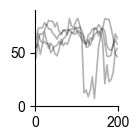

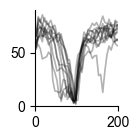

In [10]:

mice = [26, 25]
days = [19, 25]
trials_to_plot = [np.arange(130, 140),
                  np.arange(120, 140)]

for mouse, day, trial_numbers_to_plot in zip(mice, days, trials_to_plot):
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse, day, apply_zscore=False, apply_guassian_filter=False
    )
    speed_matrix, trial_type_colors, trial_order, pos_bins = get_heatmap_and_colors(
        beh, last_ephys_bin, tl, bs, sort=False
    )
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2

    trial_df = beh['trials'][:int(last_ephys_bin / (tl / bs))]
    number_to_row = {
        int(trial_df['number'][ti]): row_idx
        for row_idx, ti in enumerate(trial_order)
    }

    fig, ax = plt.subplots(figsize=(1.5, 1.5))

    for trial_num in trial_numbers_to_plot:
        row = number_to_row.get(trial_num)
        if row is None:
            continue
        ti = trial_order[row]
        trial_type = trial_df.loc[int(ti), 'type']
        if str(trial_type) != 'nb':
            continue
        profile = speed_matrix[row, :]
        ax.plot(pos_centers, profile, color='black', alpha=0.3, linewidth=1.2)

    ax.set_xlim(0, tl)
    ax.set_ylim(0, 90)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
        f'figure_3_xgboost/M{mouse}D{day}speed_selected_trials.pdf'
    )
    plt.show()


In [ ]:

mouse = 26
day = 19
gcs, ngs, all = classify_cells_both_sessions(
        mouse=mouse, day=day, percentile_threshold=95, verbose=False
    )
ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')

plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, 
                                                           label='GC', figpath=f'/Users/harryclark/Desktop/M{mouse}D{day}')
for shank in [0,1,2,3]:
    cluster_ids = ngs[ngs['shank_id'] == shank].cluster_id.values
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=cluster_ids, 
                                                               label=f'NGS Shank {shank}', 
                                                               figpath=f'/Users/harryclark/Desktop/M{mouse}D{day}')
